In [32]:
library(readxl)
library(writexl)
library(ggplot2)
library(dplyr)
library(ggExtra)
library(anthroplus)
library(scales)
library(knitr)
library(officer)
library(flextable)
library(janitor)

# source('fungsi/bmi_calc.R')
source('fungsi/bmi_calc2.R')
source('fungsi/summary.R')

In [33]:
male_data <- read_excel("raw_data/male_data.xlsx")
male_data

# A tibble: 827 × 8
   ks    tl                   umur sex      tb    bb    bf   bmi
   <chr> <dttm>              <dbl> <chr> <dbl> <dbl> <dbl> <dbl>
 1 SM71  2013-06-24 00:00:00  12.3 M      143   39.5  13.4  19.3
 2 SM72  2012-10-01 00:00:00  13   M      148.  37.5  11.1  17.2
 3 SM73  2012-12-22 00:00:00  12.8 M      158   41.8   8.1  16.7
 4 SM74  2013-02-14 00:00:00  12.6 M      160   64.7  22    25.3
 5 SM75  2013-04-30 00:00:00  12.4 M      145   45.3   0    21.5
 6 SM76  2012-10-28 00:00:00  12.9 M      166.  69.5  27.8  25.1
 7 SM77  2012-10-10 00:00:00  12.9 M      148   42.3  11.4  19.3
 8 SM78  2013-03-27 00:00:00  12.5 M      156.  44.4  12.2  18.4
 9 SM79  2013-02-02 00:00:00  12.7 M      148.  51.2  23.4  23.5
10 SM710 2012-05-20 00:00:00  13.3 M      160.  47.5  11.1  18.7
# ℹ 817 more rows
# ℹ Use `print(n = ...)` to see more rows

In [34]:
# menghitung z-scores dan kategori
male_results <- calculate_bmi_zscores(male_data, target_sex=1)

In [35]:
male_results

# A tibble: 827 × 18
   ks    tl                   umur sex      tb    bb    bf bmi_empiris
   <chr> <dttm>              <dbl> <chr> <dbl> <dbl> <dbl>       <dbl>
 1 SM71  2013-06-24 00:00:00  12.3 M      143   39.5  13.4        19.3
 2 SM72  2012-10-01 00:00:00  13   M      148.  37.5  11.1        17.2
 3 SM73  2012-12-22 00:00:00  12.8 M      158   41.8   8.1        16.7
 4 SM74  2013-02-14 00:00:00  12.6 M      160   64.7  22          25.3
 5 SM75  2013-04-30 00:00:00  12.4 M      145   45.3   0          21.5
 6 SM76  2012-10-28 00:00:00  12.9 M      166.  69.5  27.8        25.1
 7 SM77  2012-10-10 00:00:00  12.9 M      148   42.3  11.4        19.3
 8 SM78  2013-03-27 00:00:00  12.5 M      156.  44.4  12.2        18.4
 9 SM79  2013-02-02 00:00:00  12.7 M      148.  51.2  23.4        23.5
10 SM710 2012-05-20 00:00:00  13.3 M      160.  47.5  11.1        18.7
# ℹ 817 more rows
# ℹ 10 more variables: umur_bulan <dbl>, bmi_who <dbl>, bmi_z_manual <dbl>,
#   bmi_z_interp <dbl>, bmi_z_pac

In [36]:
summarize_categorical(male_results, "cat_package")

# A tibble: 7 × 3
  Category     Freq Percentage
  <chr>       <int>      <dbl>
1 Gizi Buruk     25        3  
2 Gizi Kurang    87       10.5
3 Gizi Normal   524       63.4
4 Gizi Lebih    110       13.3
5 Obesitas       75        9.1
6 NA              6        0.7
7 Total         827      100  

In [37]:
summarize_categorical(male_results, "cat_manual")

# A tibble: 7 × 3
  Category     Freq Percentage
  <chr>       <int>      <dbl>
1 Gizi Buruk     25        3  
2 Gizi Kurang    87       10.5
3 Gizi Normal   524       63.4
4 Gizi Lebih    109       13.2
5 Obesitas       76        9.2
6 NA              6        0.7
7 Total         827      100  

In [38]:
summarize_categorical(male_results, "cat_interp")

# A tibble: 7 × 3
  Category     Freq Percentage
  <chr>       <int>      <dbl>
1 Gizi Buruk     25        3  
2 Gizi Kurang    87       10.5
3 Gizi Normal   523       63.2
4 Gizi Lebih    110       13.3
5 Obesitas       76        9.2
6 NA              6        0.7
7 Total         827      100  

In [39]:
table(male_results$cat_manual == male_results$cat_package)


FALSE  TRUE 
    1   820 

In [40]:
table(male_results$cat_package == male_results$cat_interp)


FALSE  TRUE 
    2   819 

In [63]:
perbedaan_cat <- male_results %>%
  filter(cat_manual != cat_package | cat_package != cat_interp) %>%
  select(ks, umur_bulan, bmi_empiris, bmi_z_manual, bmi_z_package, bmi_z_interp, cat_manual, cat_package, cat_interp)

# Tampilkan hasil ke konsol R
perbedaan_cat

# A tibble: 2 × 9
  ks    umur_bulan bmi_empiris bmi_z_manual bmi_z_package bmi_z_interp
  <chr>      <dbl>       <dbl>        <dbl>         <dbl>        <dbl>
1 AA99        180         27          2.00              2         2.00
2 YI98        179.        22.6        1.000             1         1.00
# ℹ 3 more variables: cat_manual <ord>, cat_package <ord>, cat_interp <ord>

In [44]:
male_results %>%
  filter(umur_bulan == 180, bmi_empiris == 27) %>%
  select(umur_bulan, bmi_empiris, bmi_z_manual, bmi_z_package, bmi_z_interp) # Ganti nama kolom Z-score sesuai data Anda

# A tibble: 1 × 5
  umur_bulan bmi_empiris bmi_z_manual bmi_z_package bmi_z_interp
       <dbl>       <dbl>        <dbl>         <dbl>        <dbl>
1        180          27         2.00             2         2.00

In [45]:
summarize_continuous(male_results, "bmi_z_package")

# A tibble: 5 × 2
  Statistic    Value                 
  <chr>        <chr>                 
1 N            821                   
2 Mean ± SD    -0.242 ± 1.583        
3 Median (IQR) -0.340 (-1.340, 0.850)
4 Minimum      -5.59                 
5 Maximum      4.14                  

In [46]:
write_xlsx(male_results, "male_nutritional_status.xlsx")

In [21]:
plot_bmi_comprehensive <- function(df, bmi_col) {
  
  if (!requireNamespace("patchwork", quietly = TRUE)) install.packages("patchwork")
  if (!requireNamespace("e1071", quietly = TRUE)) install.packages("e1071")
  
  library(ggplot2)
  library(patchwork)
  library(e1071)
  
  # ==========================================
  # 1. Statistik & Preparasi Data
  # ==========================================
  x <- df[[bmi_col]][!is.na(df[[bmi_col]])]
  
  m_mean   <- mean(x)
  m_median <- median(x)
  m_sd     <- sd(x)
  m_skew   <- skewness(x)
  
  x_min <- min(x)
  x_max <- max(x)
  
  # Densitas untuk Kurva Normal
  x_range <- seq(x_min, x_max, length.out = 500)
  y_norm  <- dnorm(x_range, mean = m_mean, sd = m_sd)
  df_norm <- data.frame(x = x_range, y = y_norm)
  shade_sd <- subset(df_norm, x >= (m_mean - m_sd) & x <= (m_mean + m_sd))
  
  # Sinkronisasi sumbu Y
  dens <- density(x)
  y_max <- max(max(dens$y), max(y_norm)) * 1.15 
  
  # ==========================================
  # 2. LOGIKA ANOTASI SKEWNESS OTOMATIS (ENGLISH)
  # ==========================================
  is_right_skew <- m_skew > 0
  
  skew_label <- ifelse(is_right_skew, 
                       "Right-Skewed\n(Positive Tail)", 
                       "Left-Skewed\n(Negative Tail)")
  
  # Penempatan teks (30% dari ujung ekor)
  text_x <- ifelse(is_right_skew, 
                   x_max - (x_max - m_mean) * 0.3, 
                   x_min + (m_mean - x_min) * 0.3)
  text_y <- y_max * 0.5 # Tinggi teks
  
  # Ujung panah menunjuk ke 10% area paling ekstrem
  arrow_x <- ifelse(is_right_skew, 
                    x_max - (x_max - m_mean) * 0.1, 
                    x_min + (m_mean - x_min) * 0.1)
  arrow_y <- y_max * 0.05 
  
  # ==========================================
  # 3. PLOT KIRI: Empiris 
  # ==========================================
  p1 <- ggplot(df, aes(x = .data[[bmi_col]])) +
    geom_histogram(
      aes(y = after_stat(density)), 
      binwidth = 0.5, boundary = 0, fill = "#A8B8C6", color = "white", alpha = 0.5, na.rm = TRUE
    ) +
    geom_density(aes(color = "Empirical Density"), linewidth = 1.2, key_glyph = "path", na.rm = TRUE) +
    geom_vline(aes(xintercept = m_mean, color = "Mean"), linewidth = 1.2, linetype = "solid") +
    geom_vline(aes(xintercept = m_median, color = "Median"), linewidth = 1.2, linetype = "solid") +
    
    # Anotasi Teks Otomatis
    annotate(
      "text", x = text_x, y = text_y, label = skew_label, 
      color = "#5c5c5c", fontface = "bold", size = 4
    ) +
    
    # Panah Dinamis
    annotate(
      "curve", x = text_x, y = text_y - (y_max * 0.03), xend = arrow_x, yend = arrow_y,
      curvature = ifelse(is_right_skew, 0.3, -0.3), 
      arrow = arrow(length = unit(0.25, "cm"), type = "closed"), 
      color = "#5c5c5c", linewidth = 0.8
    ) +
    
    scale_color_manual(values = c("Empirical Density" = "#2F4858", "Mean" = "#336699", "Median" = "#CC6600")) +
    coord_cartesian(xlim = c(x_min, x_max), ylim = c(0, y_max)) +
    labs(
      title = "Empirical Distribution",
      subtitle = sprintf("Skewness: %.3f | Central Tendency", m_skew),
      x = expression(Z-Score~BMI), y = "Density"
    ) +
    theme_classic(base_size = 13) +
    theme(legend.position = "bottom", legend.title = element_blank())
    
  # ==========================================
  # 4. PLOT KANAN: Normal Teoretis
  # ==========================================
  p2 <- ggplot(df_norm, aes(x = x, y = y)) +
    geom_area(data = shade_sd, aes(x = x, y = y, fill = "±1 SD (68.3%)"), alpha = 0.3) +
    geom_line(aes(color = "Normal Curve"), linewidth = 1.2) +
    geom_vline(xintercept = c(m_mean - m_sd, m_mean + m_sd), color = "#D1495B", linetype = "dashed", linewidth = 0.8) +
    geom_vline(aes(xintercept = m_mean, color = "Mean (Center)"), linewidth = 1.2) +
    
    scale_color_manual(values = c("Normal Curve" = "#D1495B", "Mean (Center)" = "#336699")) +
    scale_fill_manual(values = c("±1 SD (68.3%)" = "#D1495B")) +
    coord_cartesian(xlim = c(x_min, x_max), ylim = c(0, y_max)) +
    labs(
      title = "Theoretical Normal Model",
      subtitle = sprintf("SD: %.2f | Expected Variance", m_sd),
      x = expression(Z-Score~BMI), y = "" 
    ) +
    theme_classic(base_size = 13) +
    theme(
      legend.position = "bottom", 
      legend.title = element_blank(),
      axis.text.y = element_blank(), 
      axis.ticks.y = element_blank(),
      axis.line.y = element_blank()
    )

  # ==========================================
  # 5. PENGGABUNGAN 
  # ==========================================
  final_plot <- p1 + p2 + 
    plot_annotation(
      # title = "BMI Distribution Audit: Empirical vs. Theoretical Expectation",
      theme = theme(plot.title = element_text(face = "bold", hjust = 0.5, size = 16))
    )
    
  return(final_plot)
}


Attaching package: ‘e1071’

The following object is masked from ‘package:ggplot2’:

    element



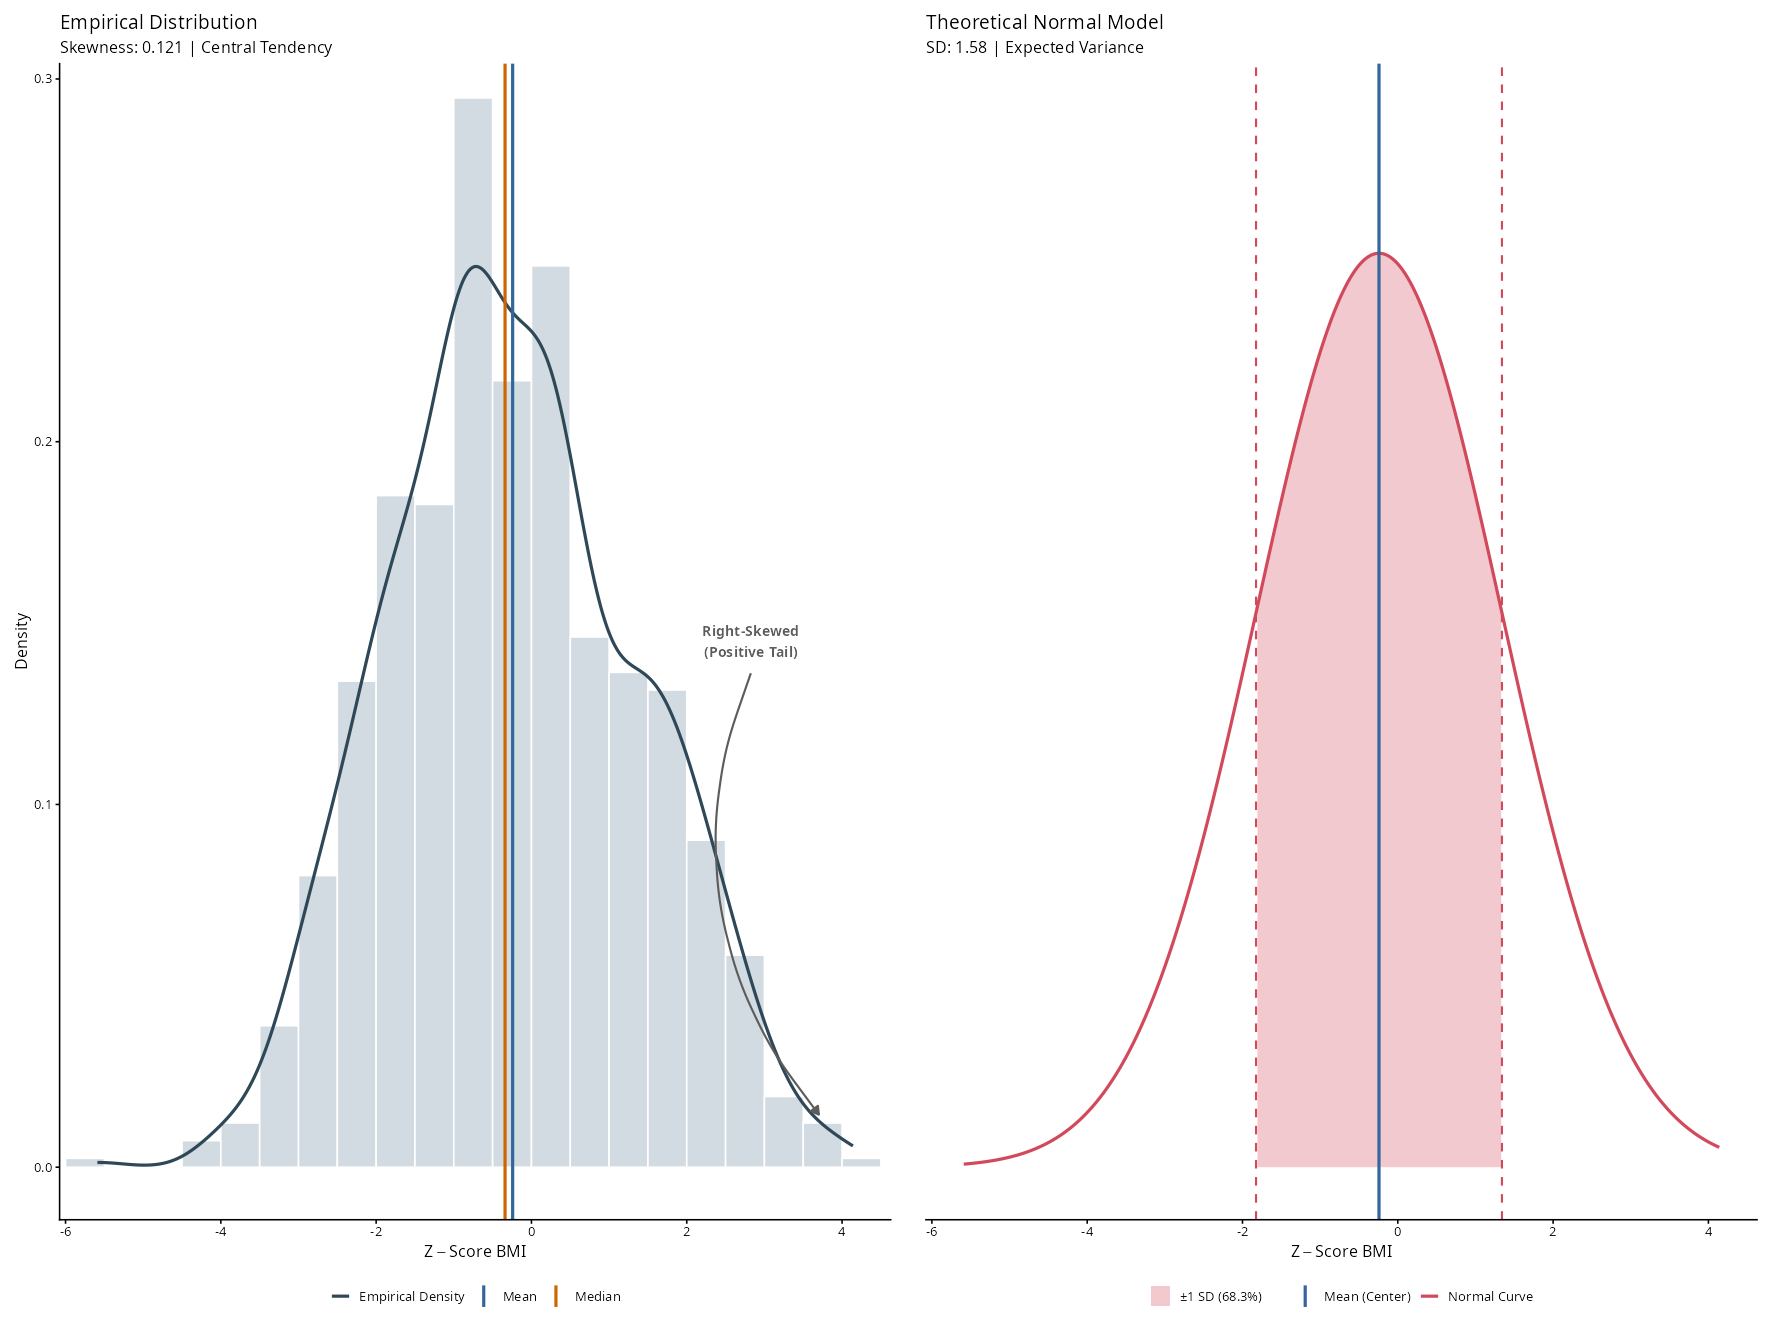

In [22]:
male_bmi_density <- plot_bmi_comprehensive(df=male_results, bmi_col = "bmi_z_package")
male_bmi_density

In [23]:
ggsave("plot/male_density_curve.png", male_bmi_density, width = 10, height = 8, units = "in", dpi=1200)

# VISUAL

In [59]:
generate_who_charts <- function(data, 
                                category_col, 
                                bmi_col = "bmi_empiris", 
                                age_col = "umur_bulan", 
                                target_sex = 1) {
  
  # =====================================================================
  # 1. PENYIAPAN DATA & STANDARISASI KOLOM
  # =====================================================================
  status_levels <- c("Gizi Buruk", "Gizi Kurang", "Gizi Normal", "Gizi Lebih", "Obesitas")
  
  plot_df <- data %>%
    rename(
      val_bmi = all_of(bmi_col),
      val_age = all_of(age_col)
    ) %>%
    # PERBAIKAN 1: Biarkan NA pada kategori tetap hidup. Hanya buang yang tidak punya koordinat umur/BMI.
    filter(!is.na(val_bmi), !is.na(val_age)) %>%
    # PERBAIKAN 2: Injeksi materialisasi NA dilakukan langsung di data utama, bukan di tabel.
    mutate(
      !!sym(category_col) := factor(.data[[category_col]], levels = status_levels),
      !!sym(category_col) := forcats::fct_na_value_to_level(.data[[category_col]], level = "Tidak Terdefinisi")
    )
  
  who_lms <- anthroplus:::bfa_growth_standards %>%
    filter(sex == target_sex) %>% arrange(age)
  
  who_curves <- who_lms %>%
    mutate(
      z_m3 = m * (1 + l*s*(-3))^(1/l), z_m2 = m * (1 + l*s*(-2))^(1/l),
      z_m1 = m * (1 + l*s*(-1))^(1/l), z_0  = m,
      z_p1 = m * (1 + l*s*(1))^(1/l), z_p2 = m * (1 + l*s*(2))^(1/l),
      z_p3 = m * (1 + l*s*(3))^(1/l)
    )
  
  min_bound <- floor(min(c(plot_df$val_bmi, who_curves$z_m3), na.rm = TRUE)) - 2
  max_bound <- ceiling(max(c(plot_df$val_bmi, who_curves$z_p3), na.rm = TRUE)) + 2
  
  zone_df <- who_curves %>%
    transmute(
      age, zm3 = z_m3, zm2 = z_m2, zp1 = z_p1, zp2 = z_p2,
      ymin = min_bound, ymax = max_bound
    )
  
  # PERBAIKAN 3: Karena plot_df sudah paten, pembuatan cat_table menjadi jauh lebih sederhana
  cat_table <- plot_df %>%
    group_by(.data[[category_col]]) %>%
    summarise(n = n(), .groups = "drop") %>%
    arrange(.data[[category_col]]) %>%
    mutate(pct = round(100 * n / sum(n), 1))
  
  # PERBAIKAN 4: Membuat label legenda HANYA untuk kategori yang valid (membuang label NA dari legenda scatter plot)
  valid_cats <- cat_table %>% filter(.data[[category_col]] != "Tidak Terdefinisi")
  legend_labels <- setNames(
    paste0(valid_cats[[category_col]], " (", valid_cats$pct, "%)"),
    valid_cats[[category_col]]
  )
  
  label_df <- data.frame(
    age = max(who_curves$age) + 3,
    val_bmi = c(
      dplyr::last(who_curves$z_m3), dplyr::last(who_curves$z_m2), dplyr::last(who_curves$z_m1),
      dplyr::last(who_curves$z_0),  dplyr::last(who_curves$z_p1), dplyr::last(who_curves$z_p2),
      dplyr::last(who_curves$z_p3)
    ),
    label = c("-3", "-2", "-1", "0", "+1", "+2", "+3")
  )
  
  who_curves_long <- who_curves %>%
    pivot_longer(cols = starts_with("z_"), names_to = "curve", values_to = "value") %>%
    mutate(curve = factor(curve, levels = c("z_m3", "z_m2", "z_m1", "z_0", "z_p1", "z_p2", "z_p3")))

  # =====================================================================
  # 2. MESIN DETEKSI EKSPLOSI SE MATEMATIS (TWO-TAILED)
  # =====================================================================
  loess_model <- loess(val_bmi ~ val_age, data = plot_df, span = 0.9, 
                       control = loess.control(surface = "direct"))
  
  age_seq <- sort(unique(plot_df$val_age))
  loess_pred <- predict(loess_model, newdata = data.frame(val_age = age_seq), se = TRUE)
  se_values <- loess_pred$se.fit
  
  se_baseline <- median(se_values, na.rm = TRUE)
  se_mad <- mad(se_values, na.rm = TRUE)
  se_threshold <- se_baseline + (3 * se_mad) 
  
  mid_age <- median(age_seq, na.rm = TRUE)
  
  upper_explosion <- age_seq[age_seq > mid_age & se_values > se_threshold]
  dynamic_upper_cutoff <- if (length(upper_explosion) > 0) min(upper_explosion) else max(age_seq, na.rm = TRUE)
  
  lower_explosion <- age_seq[age_seq < mid_age & se_values > se_threshold]
  dynamic_lower_cutoff <- if (length(lower_explosion) > 0) max(lower_explosion) else min(age_seq, na.rm = TRUE)
  
  max_bmi <- max(plot_df$val_bmi, na.rm = TRUE)
  min_bmi <- min(plot_df$val_bmi, na.rm = TRUE)

  # =====================================================================
  # 3. PENGATURAN PLOT
  # =====================================================================
  master_colors <- c(
    "Gizi Buruk" = "#31688e", "Gizi Kurang" = "#639bb4", "Gizi Normal" = "#d9d9d9",
    "Gizi Lebih" = "#e07a5f", "Obesitas" = "#b11226"
  )
  
  shared_layers <- list(
    # PERBAIKAN 5: Filter NA agar tidak menjadi titik (dot) di scatter plot
    geom_point(
      data = plot_df %>% filter(.data[[category_col]] != "Tidak Terdefinisi"), 
      aes(val_age, val_bmi, fill = .data[[category_col]]), 
      shape = 21, color = "white", alpha = 0.8, size = 2.8
    ),
    geom_text(data = label_df, aes(age, val_bmi, label = label), hjust = 0, size = 5),
    
    # PERBAIKAN 6: Paksa legenda hanya memunculkan yang ada di `legend_labels` menggunakan 'breaks'
    scale_fill_manual(
      values = master_colors, 
      labels = legend_labels,
      breaks = names(legend_labels)
    ),
    
    coord_cartesian(xlim = c(125, max(who_curves$age) + 15)),
    scale_x_continuous(expand = expansion(mult = c(0, 0.08))),
    theme_classic(base_size = 16),
    theme(legend.position = "bottom", legend.title = element_blank()),
    labs(subtitle = NULL, x = "Age (months)", y = expression(BMI~(kg/m^2)))
  )
  
  clean_colors <- c("z_m3"="#31688e", "z_m2"="#639bb4", "z_m1"="grey50", "z_0"="grey40", "z_p1"="grey50", "z_p2"="#e07a5f", "z_p3"="#b11226")
  clean_lines  <- c("z_m3"="solid", "z_m2"="solid", "z_m1"="dotted", "z_0"="solid", "z_p1"="dotted", "z_p2"="solid", "z_p3"="solid")
  clean_sizes  <- c("z_m3"=0.7, "z_m2"=0.7, "z_m1"=0.6, "z_0"=1.0, "z_p1"=0.6, "z_p2"=0.7, "z_p3"=0.7)
  
  base_clean_plot <- ggplot() +
    geom_line(data = who_curves_long, aes(age, value, group = curve, color = curve, linetype = curve, linewidth = curve)) +
    scale_color_manual(values = clean_colors) + scale_linetype_manual(values = clean_lines) + scale_linewidth_manual(values = clean_sizes) +
    guides(color = "none", linetype = "none", linewidth = "none") +
    shared_layers

  # --- PLOT 1: FULL LOESS DENGAN ANOTASI DUA SISI ---
  plot_clean_full <- base_clean_plot +
    geom_vline(xintercept = dynamic_upper_cutoff, linetype = "dashed", color = "black", linewidth = 0.8) +
    annotate("segment", x = dynamic_upper_cutoff - 20, xend = dynamic_upper_cutoff - 1, 
             y = max_bmi, yend = max_bmi, 
             arrow = arrow(length = unit(0.2, "cm"), type = "closed"), 
             color = "black", linewidth = 0.6) +
    annotate("text", x = dynamic_upper_cutoff - 22, y = max_bmi, 
             label = sprintf("Upper Cutoff:\nSE > 3 MAD\nat %.1f mo", dynamic_upper_cutoff), 
             hjust = 1, size = 4, fontface = "italic", lineheight = 1.1) +
    geom_vline(xintercept = dynamic_lower_cutoff, linetype = "dashed", color = "black", linewidth = 0.8) +
    annotate("segment", x = dynamic_lower_cutoff + 20, xend = dynamic_lower_cutoff + 1, 
             y = max_bmi - 3, yend = max_bmi - 3, 
             arrow = arrow(length = unit(0.2, "cm"), type = "closed"), 
             color = "black", linewidth = 0.6) +
    annotate("text", x = dynamic_lower_cutoff + 22, y = max_bmi - 3, 
             label = sprintf("Lower Cutoff:\nSE > 3 MAD\nat %.1f mo", dynamic_lower_cutoff), 
             hjust = 0, size = 4, fontface = "italic", lineheight = 1.1) +
    geom_smooth(data = plot_df, aes(val_age, val_bmi), method = "loess", span = 0.9, 
                se = TRUE, fill = "grey60", alpha = 0.4, linewidth = 1.2, color = "black")
  
  # --- PLOT 2: TRIMMED LOESS (Dipotong Kiri dan Kanan) ---
  plot_clean_trimmed <- base_clean_plot +
    geom_smooth(data = plot_df %>% filter(val_age >= dynamic_lower_cutoff & val_age <= dynamic_upper_cutoff), 
                aes(val_age, val_bmi), method = "loess", span = 0.9, 
                se = FALSE, linewidth = 1.2, color = "black")

  # --- PLOT 3: ZONE PLOT ---
  zone_lines <- c("z_m3"="dashed", "z_m2"="dashed", "z_m1"="dotted", "z_0"="solid", "z_p1"="dotted", "z_p2"="dashed", "z_p3"="dashed")
  zone_sizes <- c("z_m3"=0.6, "z_m2"=0.6, "z_m1"=0.6, "z_0"=1.0, "z_p1"=0.6, "z_p2"=0.6, "z_p3"=0.6)
  
  plot_zone <- ggplot() +
    geom_ribbon(data = zone_df, aes(age, ymin = ymin, ymax = zm3), fill = "#31688e", alpha = 0.05) +
    geom_ribbon(data = zone_df, aes(age, ymin = zm3, ymax = zm2), fill = "#639bb4", alpha = 0.05) +
    geom_ribbon(data = zone_df, aes(age, ymin = zm2, ymax = zp1), fill = "#d9d9d9", alpha = 0.08) +
    geom_ribbon(data = zone_df, aes(age, ymin = zp1, ymax = zp2), fill = "#e07a5f", alpha = 0.05) +
    geom_ribbon(data = zone_df, aes(age, ymin = zp2, ymax = ymax), fill = "#b11226", alpha = 0.05) +
    geom_line(data = who_curves_long, aes(age, value, group = curve, linetype = curve, linewidth = curve)) +
    scale_linetype_manual(values = zone_lines) + scale_linewidth_manual(values = zone_sizes) +
    guides(linetype = "none", linewidth = "none") +
    shared_layers +
    geom_smooth(data = plot_df %>% filter(val_age >= dynamic_lower_cutoff & val_age <= dynamic_upper_cutoff), 
                aes(val_age, val_bmi), method = "loess", span = 0.9, se = FALSE, linewidth = 1.2, color = "black") +
    labs(title = "WHO BMI-for-Age Growth Chart")
    
  # --- PLOT 4: BAR PLOT DISTRIBUTION ---
  urutan_asli <- setdiff(as.character(unique(cat_table[[category_col]])), "Tidak Terdefinisi")

  plot_dist <- ggplot(
      data = cat_table %>% filter(.data[[category_col]] != "Tidak Terdefinisi"), 
      aes(x = .data[[category_col]], y = pct, fill = .data[[category_col]])
    ) +
    geom_col(width = 0.7, color = "black", linewidth = 0.25) +
    geom_text(aes(label = sprintf("%.1f%%", pct)), vjust = -0.5, size = 5, fontface = "bold") +
    scale_fill_manual(values = master_colors) +
    scale_x_discrete(limits = urutan_asli) +
    scale_y_continuous(labels = scales::label_percent(scale = 1), expand = expansion(mult = c(0, 0.15))) +
    theme_minimal(base_size = 18) +
    theme(
      legend.position = "none",
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank(),
      axis.text = element_text(color = "black"),
      axis.line.y = element_line(color = "black", linewidth = 0.5)
    ) +
    labs(title = NULL, x = NULL, y = "Percentage (%)")
  
  # =====================================================================
  # 4. EXPORT HASIL
  # =====================================================================
  list(
    clean_plot_full = plot_clean_full, 
    clean_plot_trimmed = plot_clean_trimmed, 
    zone_plot = plot_zone, 
    bar_plot = plot_dist,
    calculated_upper_cutoff = dynamic_upper_cutoff,
    calculated_lower_cutoff = dynamic_lower_cutoff
  )
}

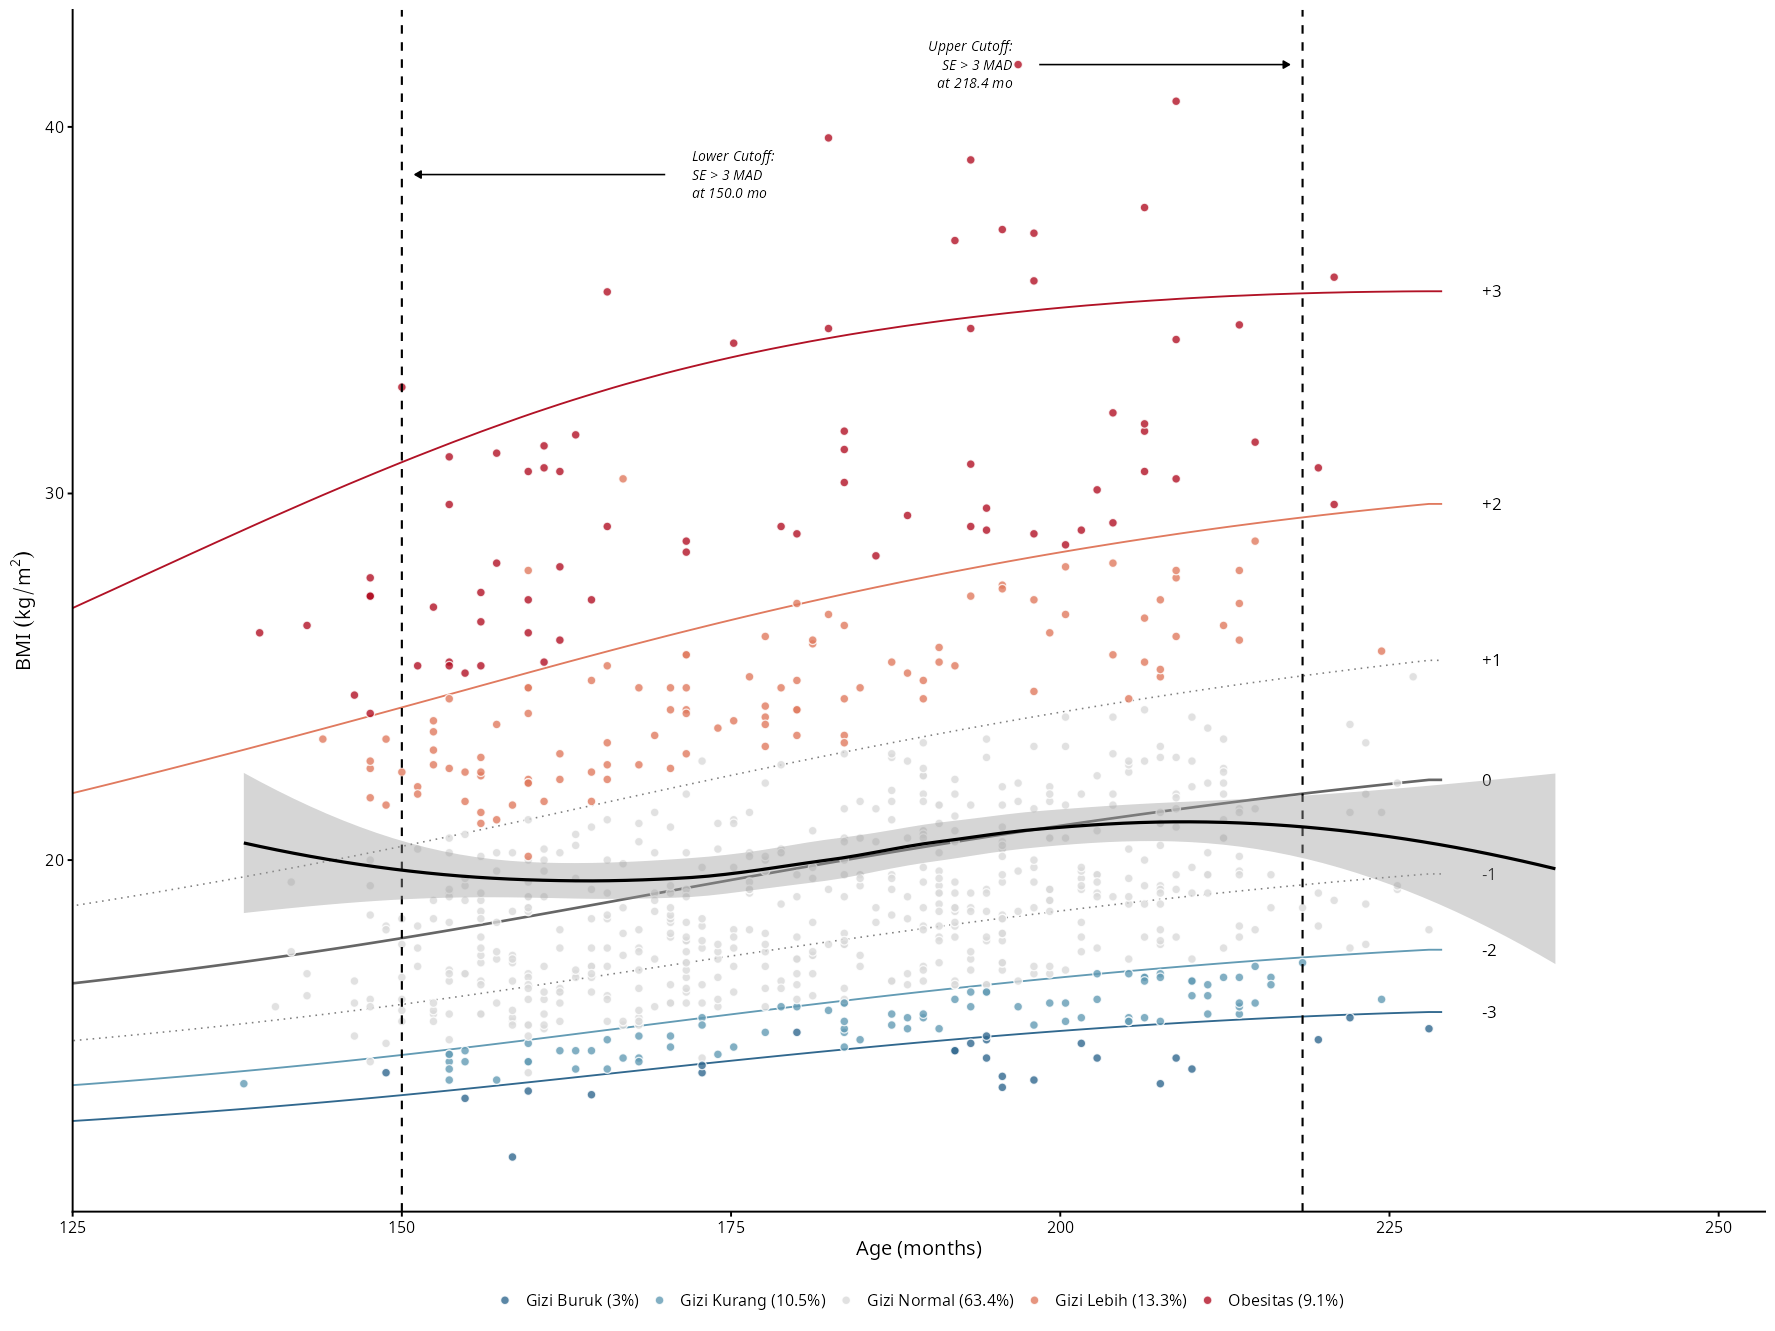

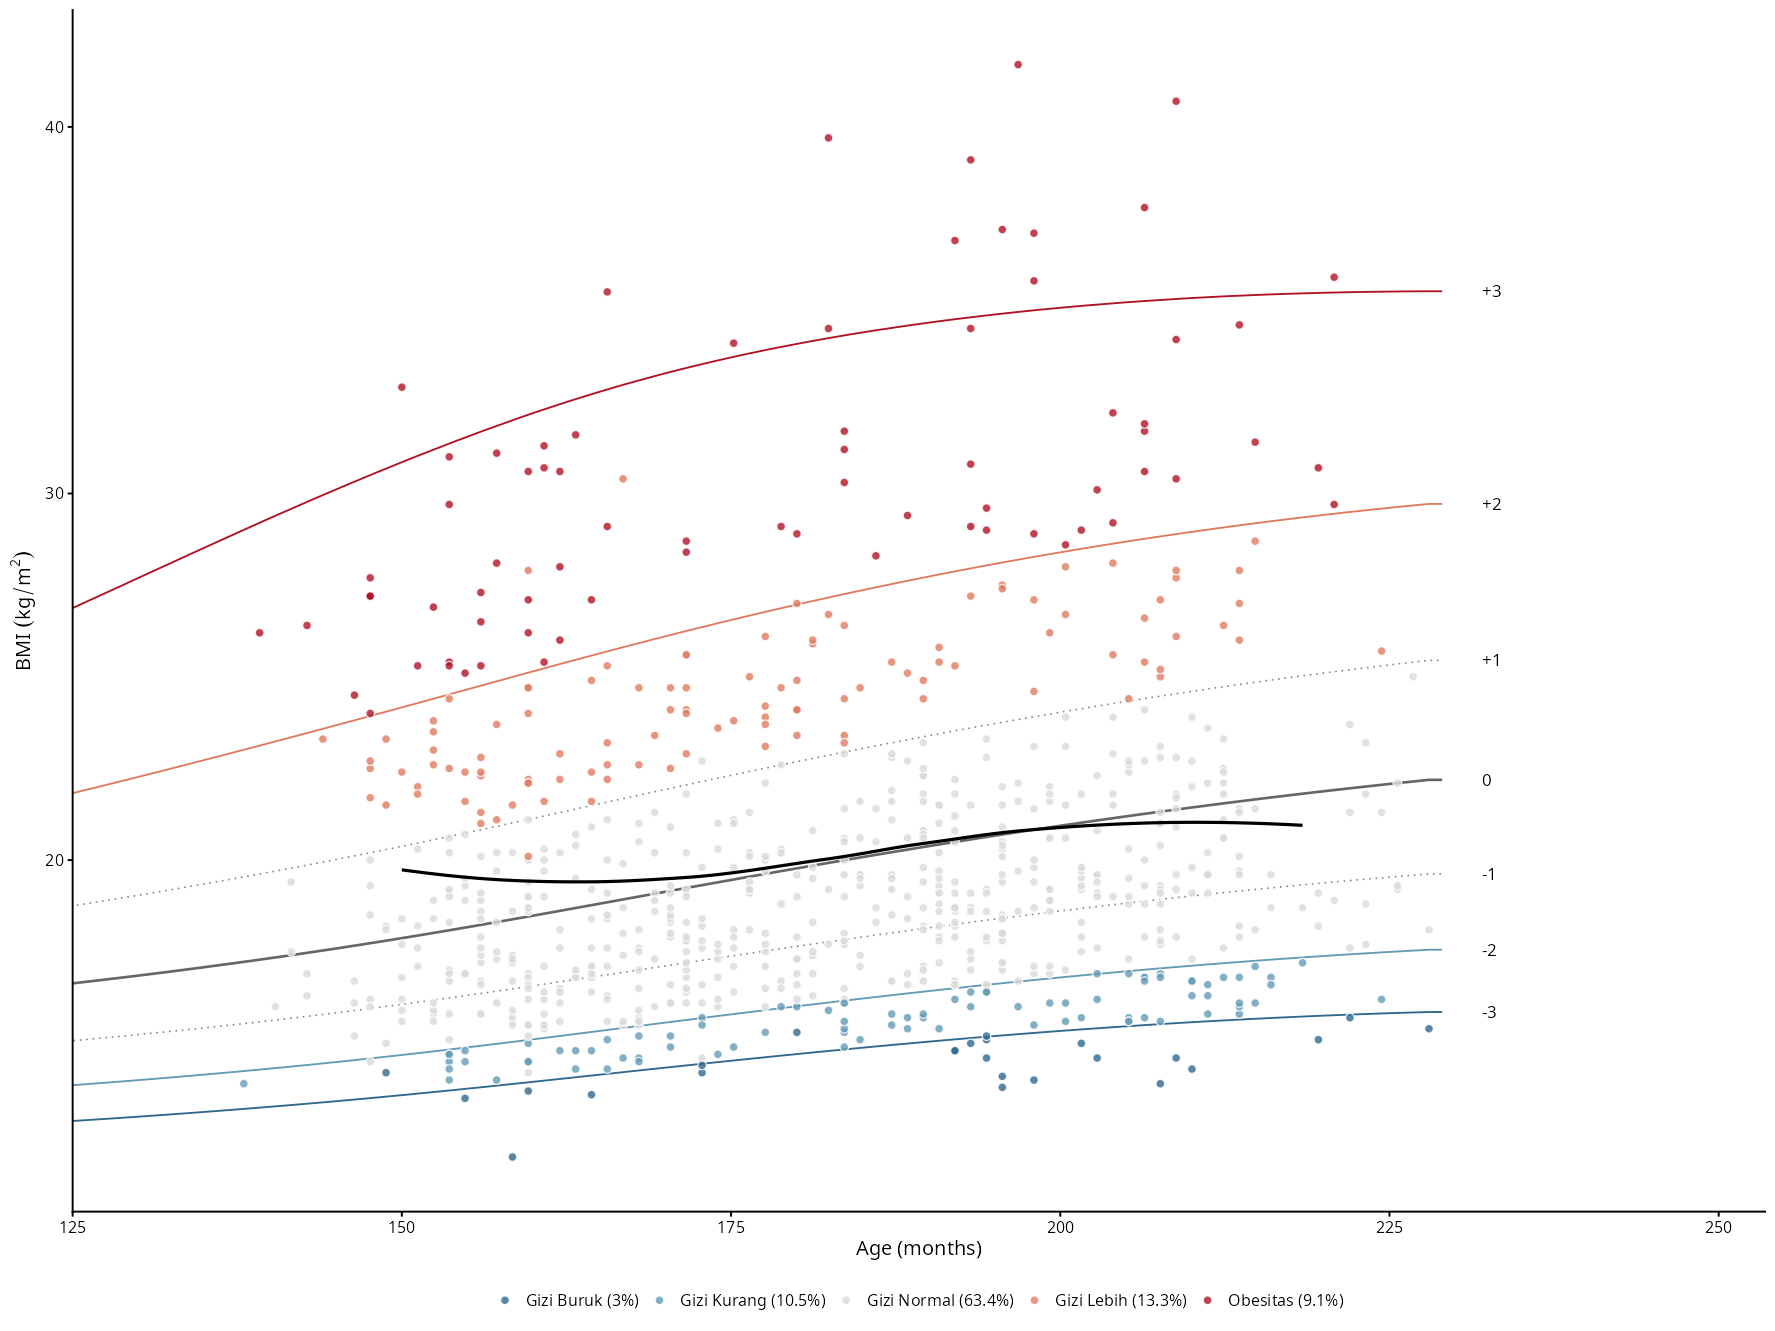

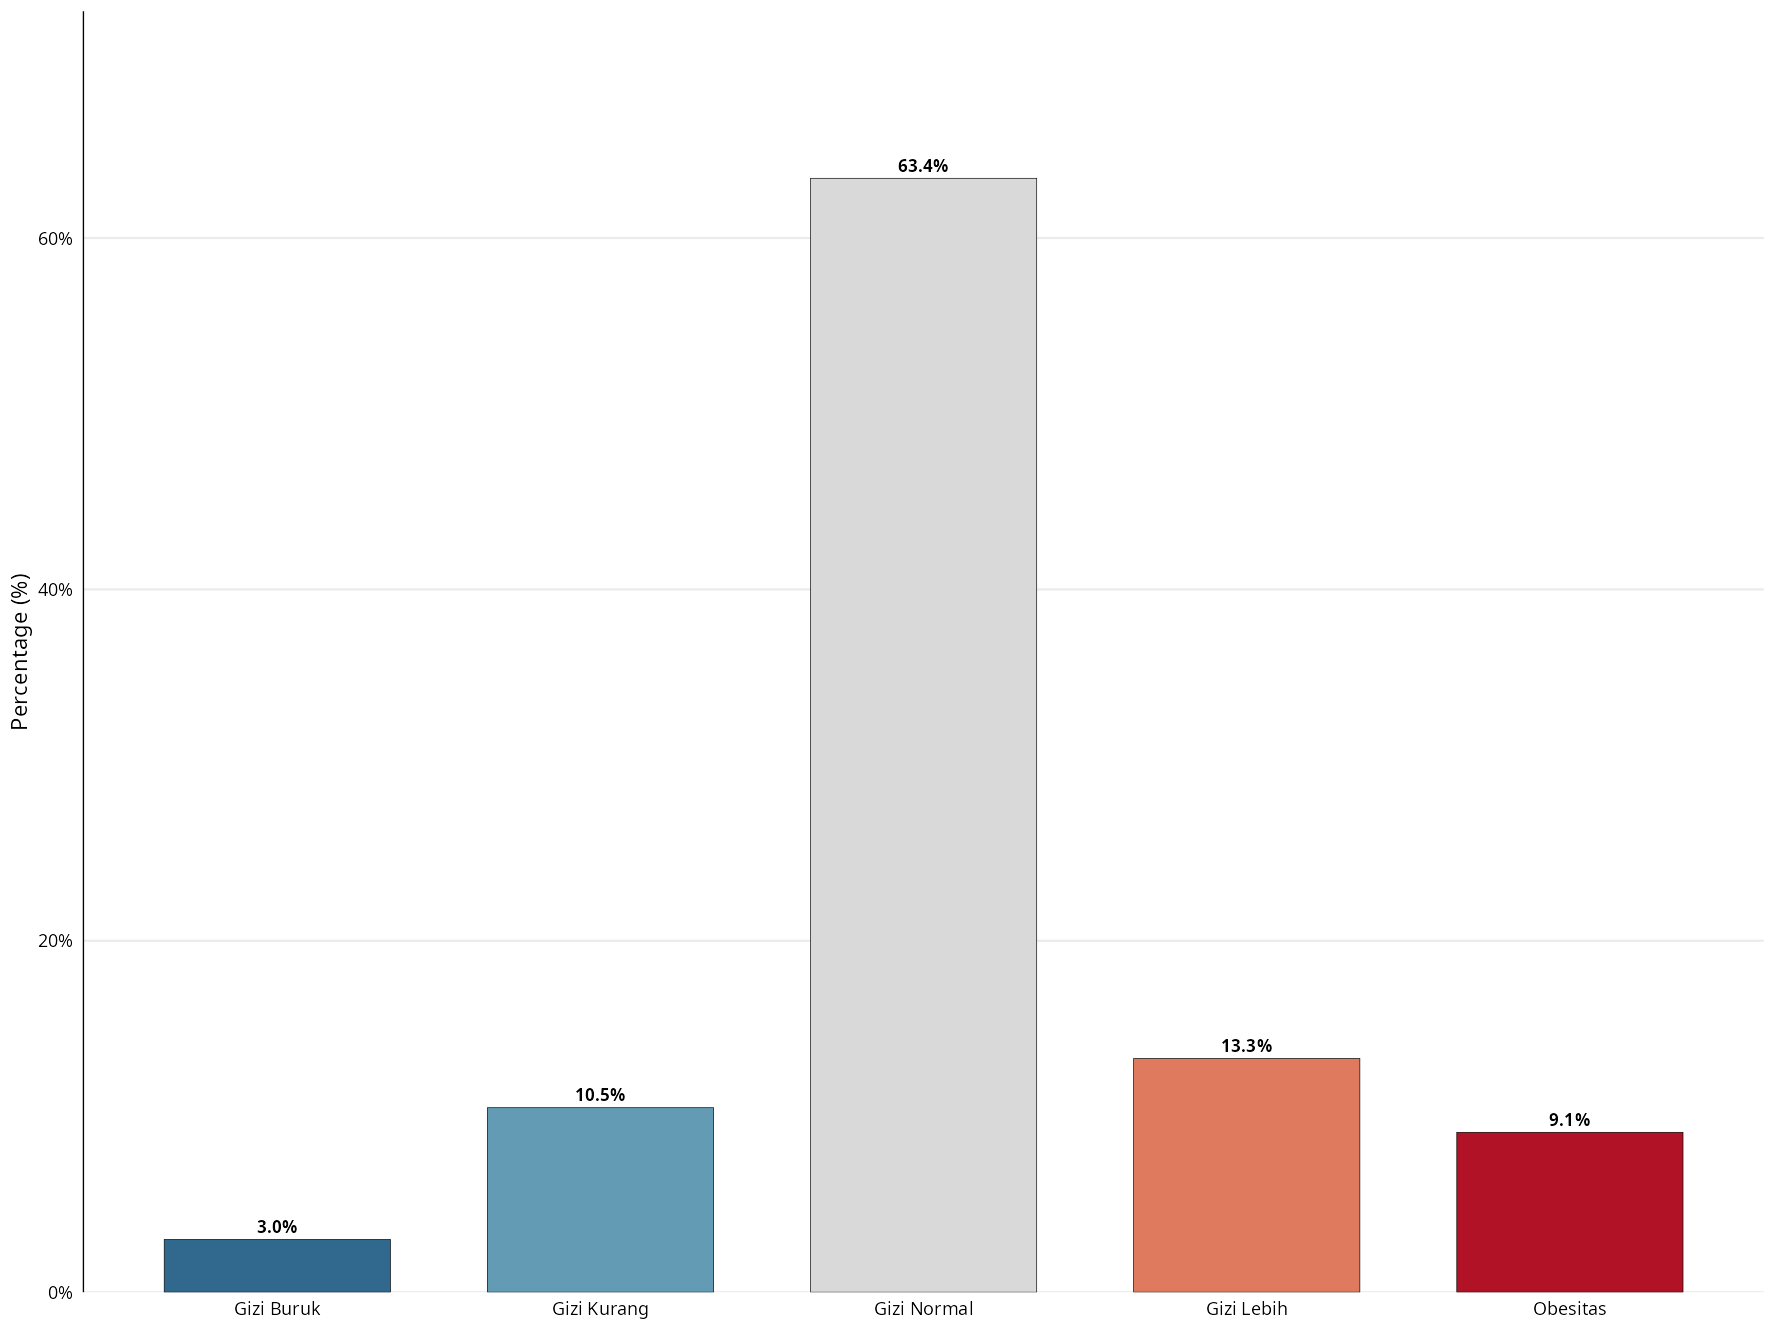

In [60]:
hasil_plot <- generate_who_charts(
  data = male_results, 
  category_col = "cat_package",
  target_sex = 1
)

# Menampilkan plot
hasil_plot$clean_plot_full
hasil_plot$clean_plot_trimmed
hasil_plot$bar_plot

# Kasus 2: Tabel data baru dimana nama kolomnya murni bmi dan umur
# hasil_plot <- generate_who_charts(
  # data = dataset_baru, 
  # category_col = "status_gizi",
  # bmi_col = "bmi",          # Tinggal oper nama kolomnya di sini
  # age_col = "umur",         # Dan di sini
  # target_sex = 2
# )

In [61]:
ggsave('plot/male_growth_chart_full.png', hasil_plot$clean_plot_full, width = 12, height = 9, dpi=1200)
ggsave('plot/male_growth_chart_trimmed.png', hasil_plot$clean_plot_trimmed, width = 12, height = 9, dpi=1200)
ggsave('plot/male_nutritional_dist_status.png', hasil_plot$bar_plot, width = 10, height = 9, dpi=1200)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
